In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torchani
import os
import matplotlib.pyplot as plt
import pandas as pd
import itertools
import ast
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

print("torch:", torch.__version__)
print("torchani:", torchani.__version__)

torch: 2.3.1+cu118
torchani: 2.2.4


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Set up AEV Computer and Load Dataset

In [3]:
def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

384


In [4]:
def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

dataset = load_ani_dataset("/global/scratch/users/mahikabansal/c142_project/ani_gdb_s01_to_s04.h5")
# Use dataset.split method to do split
train_data, val_data, test_data = dataset.split(0.8, 0.1, None)

### Define the ANITrainer Class

In [5]:
class ANITrainer:
    def __init__(self, model, batch_size=256, learning_rate=5e-4, epoch=30, l2=1e-6):
        self.model = model
        
        self.batch_size = batch_size
        num_params = sum(p.numel() for p in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        self.optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2)
        self.epoch = epoch


    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(self.batch_size).cache()
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            n_total= 0.0
            for train_data_batch in train_data_loader:
                
                # compute energies
                species = train_data_batch['species'].to(device)
                coords = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(true_energies, pred_energies)
                
                # do a step
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = true_energies.shape[0]
                train_epoch_loss += batch_loss.item() * batch_importance
                n_total += batch_importance
            
            train_epoch_loss /= max(n_total, 1)
            # use the self.evaluate to get loss on the validation set 
            _, val_mae = self.evaluate(val_data, draw_plot=False, return_mae=True)
            
            # append the losses
            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_mae)
            
            if early_stop:
                if val_mae < lowest_val_loss:
                    lowest_val_loss = val_mae
                    weights = {k: v.clone() for k, v in self.model.state_dict().items()}
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            ax.plot(range(len(train_loss_list)), train_loss_list, label='Train')
            ax.plot(range(len(val_loss_list)), val_loss_list, label='Validation MAE (kcal/mol)')
            ax.legend()
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False, return_mae=False):

        self.model.eval()
        
        # init data loader
        data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        
        if draw_plot or return_mae:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data_loader:
                
                # compute energies
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                species_out, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(true_energies, pred_energies)

                batch_importance = true_energies.shape[0]
                total_loss += batch_loss.item() * batch_importance
                
                if draw_plot or return_mae:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())


        mae = None
        if draw_plot or return_mae:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777
            mae = np.mean(np.abs(true_energies_all - pred_energies_all)) * hartree2kcalmol

        if draw_plot:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()

        if return_mae:
            return total_loss, mae

        return total_loss       

### Define Model Architecture and Hyperparameter Search

In [6]:
class AtomicNet(nn.Module):
    def __init__(self, aev_dim, hidden_layers, dropout=0.0):
        super().__init__()
        layers = []
        in_dim = aev_dim
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 1))
        self.layers = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.layers(x)

def build_model(aev_computer, aev_dim, hidden_layers, dropout):
    # Initialize fresh atomic networks for each element (H, C, N, O)
    net_H = AtomicNet(aev_dim, hidden_layers, dropout)
    net_C = AtomicNet(aev_dim, hidden_layers, dropout)
    net_N = AtomicNet(aev_dim, hidden_layers, dropout)
    net_O = AtomicNet(aev_dim, hidden_layers, dropout)

    ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
    model = nn.Sequential(
        aev_computer,
        ani_net
    ).to(device)
    return model

In [7]:
# Hyperparameter Grid - One Hidden Layer
hidden_layers_list = [
    [128]
]
learning_rates = [1e-3, 1e-4]
epochs_list    = [10]           
l2_list        = [1e-5]
dropout_list   = [0.0, 0.1]

results = []

for hidden_layers, lr, epochs, l2, dropout in itertools.product(
    hidden_layers_list, learning_rates, epochs_list, l2_list, dropout_list
):
    print(f"Training: hidden={hidden_layers}, lr={lr}, epochs={epochs}, l2={l2}, dropout={dropout}")
    
    model = build_model(aev_computer, aev_dim, hidden_layers, dropout)
    trainer = ANITrainer(model, 256, lr, epochs, l2)
    
    train_losses, val_losses = trainer.train(train_data, val_data, draw_curve=False)
    
    _, train_mae = trainer.evaluate(train_data, return_mae=True)
    _, val_mae   = trainer.evaluate(val_data,   return_mae=True)
    _, test_mae  = trainer.evaluate(test_data,  return_mae=True)
    
    results.append({
        'Hidden Layers':          str(hidden_layers),
        'Learning Rate':          lr,
        'Epochs':                 epochs,
        'L2 Regularization':      l2,
        'Dropouts':               dropout,
        'Train MAE (kcal/mol)':   round(train_mae, 2),
        'Validation MAE (kcal/mol)': round(val_mae, 2),
        'Test MAE (kcal/mol)':    round(test_mae, 2),
    })
    
    print(f"  -> Train MAE: {train_mae:.2f}, Val MAE: {val_mae:.2f}, Test MAE: {test_mae:.2f}\n")


Training: hidden=[128], lr=0.001, epochs=10, l2=1e-05, dropout=0.0
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [03:25<00:00, 20.53s/it]


  -> Train MAE: 1.68, Val MAE: 1.69, Test MAE: 1.67

Training: hidden=[128], lr=0.001, epochs=10, l2=1e-05, dropout=0.1
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [03:29<00:00, 20.94s/it]


  -> Train MAE: 1.56, Val MAE: 1.57, Test MAE: 1.56

Training: hidden=[128], lr=0.0001, epochs=10, l2=1e-05, dropout=0.0
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [03:27<00:00, 20.78s/it]


  -> Train MAE: 1.24, Val MAE: 1.24, Test MAE: 1.23

Training: hidden=[128], lr=0.0001, epochs=10, l2=1e-05, dropout=0.1
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [03:30<00:00, 21.03s/it]


  -> Train MAE: 1.22, Val MAE: 1.23, Test MAE: 1.21



In [8]:
# Hyperparameter Grid - Two Hidden Layers
hidden_layers_list = [
    [256, 128]
]
learning_rates = [1e-3, 1e-4]
epochs_list    = [10]           
l2_list        = [1e-5]
dropout_list   = [0.0, 0.1]

for hidden_layers, lr, epochs, l2, dropout in itertools.product(
    hidden_layers_list, learning_rates, epochs_list, l2_list, dropout_list
):
    print(f"Training: hidden={hidden_layers}, lr={lr}, epochs={epochs}, l2={l2}, dropout={dropout}")
    
    model = build_model(aev_computer, aev_dim, hidden_layers, dropout)
    trainer = ANITrainer(model, 256, lr, epochs, l2)
    
    train_losses, val_losses = trainer.train(train_data, val_data, draw_curve=False)
    
    _, train_mae = trainer.evaluate(train_data, return_mae=True)
    _, val_mae   = trainer.evaluate(val_data,   return_mae=True)
    _, test_mae  = trainer.evaluate(test_data,  return_mae=True)
    
    results.append({
        'Hidden Layers':          str(hidden_layers),
        'Learning Rate':          lr,
        'Epochs':                 epochs,
        'L2 Regularization':      l2,
        'Dropouts':               dropout,
        'Train MAE (kcal/mol)':   round(train_mae, 2),
        'Validation MAE (kcal/mol)': round(val_mae, 2),
        'Test MAE (kcal/mol)':    round(test_mae, 2),
    })
    
    print(f"  -> Train MAE: {train_mae:.2f}, Val MAE: {val_mae:.2f}, Test MAE: {test_mae:.2f}\n")

Training: hidden=[256, 128], lr=0.001, epochs=10, l2=1e-05, dropout=0.0
Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 10/10 [03:47<00:00, 22.78s/it]


  -> Train MAE: 1.57, Val MAE: 1.59, Test MAE: 1.57

Training: hidden=[256, 128], lr=0.001, epochs=10, l2=1e-05, dropout=0.1
Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 10/10 [03:47<00:00, 22.76s/it]


  -> Train MAE: 1.63, Val MAE: 1.65, Test MAE: 1.63

Training: hidden=[256, 128], lr=0.0001, epochs=10, l2=1e-05, dropout=0.0
Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 10/10 [03:39<00:00, 21.99s/it]


  -> Train MAE: 1.33, Val MAE: 1.34, Test MAE: 1.32

Training: hidden=[256, 128], lr=0.0001, epochs=10, l2=1e-05, dropout=0.1
Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 10/10 [03:43<00:00, 22.37s/it]


  -> Train MAE: 1.36, Val MAE: 1.37, Test MAE: 1.35



In [9]:
# Hyperparameter Grid - Three Hidden Layers
hidden_layers_list = [
    [256, 128, 64]
]
learning_rates = [1e-3, 1e-4]
epochs_list    = [10]           
l2_list        = [1e-5]
dropout_list   = [0.0, 0.1]

for hidden_layers, lr, epochs, l2, dropout in itertools.product(
    hidden_layers_list, learning_rates, epochs_list, l2_list, dropout_list
):
    print(f"Training: hidden={hidden_layers}, lr={lr}, epochs={epochs}, l2={l2}, dropout={dropout}")
    
    model = build_model(aev_computer, aev_dim, hidden_layers, dropout)
    trainer = ANITrainer(model, 256, lr, epochs, l2)
    
    train_losses, val_losses = trainer.train(train_data, val_data, draw_curve=False)
    
    _, train_mae = trainer.evaluate(train_data, return_mae=True)
    _, val_mae   = trainer.evaluate(val_data,   return_mae=True)
    _, test_mae  = trainer.evaluate(test_data,  return_mae=True)
    
    results.append({
        'Hidden Layers':          str(hidden_layers),
        'Learning Rate':          lr,
        'Epochs':                 epochs,
        'L2 Regularization':      l2,
        'Dropouts':               dropout,
        'Train MAE (kcal/mol)':   round(train_mae, 2),
        'Validation MAE (kcal/mol)': round(val_mae, 2),
        'Test MAE (kcal/mol)':    round(test_mae, 2),
    })
    
    print(f"  -> Train MAE: {train_mae:.2f}, Val MAE: {val_mae:.2f}, Test MAE: {test_mae:.2f}\n")

Training: hidden=[256, 128, 64], lr=0.001, epochs=10, l2=1e-05, dropout=0.0
Sequential - Number of parameters: 559108
Initialize training data...


100%|██████████| 10/10 [04:02<00:00, 24.27s/it]


  -> Train MAE: 1.83, Val MAE: 1.84, Test MAE: 1.83

Training: hidden=[256, 128, 64], lr=0.001, epochs=10, l2=1e-05, dropout=0.1
Sequential - Number of parameters: 559108
Initialize training data...


100%|██████████| 10/10 [04:11<00:00, 25.15s/it]


  -> Train MAE: 1.78, Val MAE: 1.80, Test MAE: 1.78

Training: hidden=[256, 128, 64], lr=0.0001, epochs=10, l2=1e-05, dropout=0.0
Sequential - Number of parameters: 559108
Initialize training data...


100%|██████████| 10/10 [04:09<00:00, 24.96s/it]


  -> Train MAE: 1.49, Val MAE: 1.50, Test MAE: 1.48

Training: hidden=[256, 128, 64], lr=0.0001, epochs=10, l2=1e-05, dropout=0.1
Sequential - Number of parameters: 559108
Initialize training data...


100%|██████████| 10/10 [04:13<00:00, 25.31s/it]


  -> Train MAE: 1.52, Val MAE: 1.53, Test MAE: 1.52



### Hyperparameter Search Results

In [10]:
# Display results table sorted by test MAE
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test MAE (kcal/mol)').reset_index(drop=True)
results_df.index += 1  # 1-indexed for readability
display(results_df)

,Hidden Layers,Learning Rate,Epochs,L2 Regularization,Dropouts,Train MAE (kcal/mol),Validation MAE (kcal/mol),Test MAE (kcal/mol)
1,[128],0.0001,10,0.00001,0.1,1.22,1.23,1.21
2,[128],0.0001,10,0.00001,0.0,1.24,1.24,1.23
3,"[256, 128]",0.0001,10,0.00001,0.0,1.33,1.34,1.32
4,"[256, 128]",0.0001,10,0.00001,0.1,1.36,1.37,1.35
5,"[256, 128, 64]",0.0001,10,0.00001,0.0,1.49,1.50,1.48
6,"[256, 128, 64]",0.0001,10,0.00001,0.1,1.52,1.53,1.52
7,[128],0.0010,10,0.00001,0.1,1.56,1.57,1.56
8,"[256, 128]",0.0010,10,0.00001,0.0,1.57,1.59,1.57
9,"[256, 128]",0.0010,10,0.00001,0.1,1.63,1.65,1.63
10,[128],0.0010,10,0.00001,0.0,1.68,1.69,1.67


### Retrain and Evaluate Best Model

Best hyperparameters:
Hidden Layers                  [128]
Learning Rate                 0.0001
Epochs                            10
L2 Regularization            0.00001
Dropouts                         0.1
Train MAE (kcal/mol)            1.22
Validation MAE (kcal/mol)       1.23
Test MAE (kcal/mol)             1.21
Name: 1, dtype: object

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [06:18<00:00, 37.83s/it]


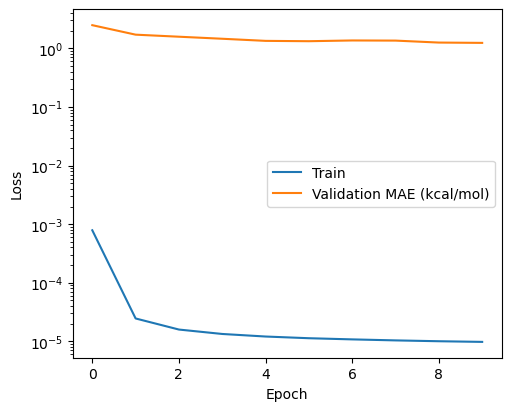

In [11]:
# Get the best hyperparameters from the results table
best = results_df.iloc[0]
print("Best hyperparameters:")
print(best)
print()

# Parse the best hidden layers back from string to list
best_hidden = ast.literal_eval(best['Hidden Layers'])
best_lr = best['Learning Rate']
best_epochs = int(best['Epochs'])
best_l2 = best['L2 Regularization']
best_dropout = best['Dropouts']

# Re-initialize and retrain the best model
best_model = build_model(aev_computer, aev_dim, best_hidden, best_dropout)
best_trainer = ANITrainer(best_model, 128, best_lr, best_epochs, best_l2)
train_losses, val_losses = best_trainer.train(train_data, val_data, draw_curve=True)

Test loss (weighted MSE sum): 0.754189
Test MAE: 1.22 kcal/mol


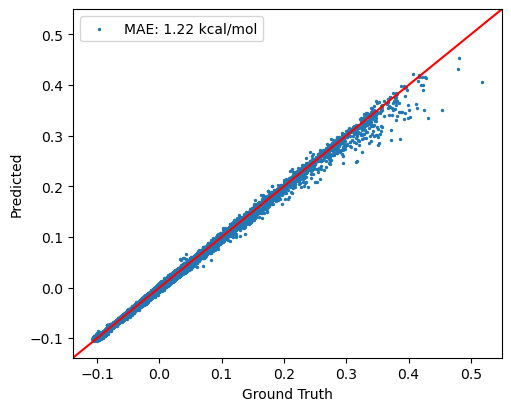

In [12]:
# Evaluate best model on the test set
test_loss, test_mae = best_trainer.evaluate(test_data, draw_plot=True, return_mae=True)
print(f"Test loss (weighted MSE sum): {test_loss:.6f}")
print(f"Test MAE: {test_mae:.2f} kcal/mol")

The best model is the one with hyperparameters of hidden layer of of just 128, a learning rate of 0.0001, L2 regularization of 0.00001, and dropout of 0.1 tested on 10 epochs. This is based on all of the training with different subsets of hyperparameters with the lowest training MAE is 1.22 kcal/mol. This model provided the best balance between fitting the training data and generalizing to unseen data, as reflected in its validation performance of this subset of hyperparameters. Also, when testing this tuned model on the test data there is an MAE of 1.22 kcal/mol which is similar to the training MAE. This means that the model learned the dataset pattern well, generalizes to unseen data, and has low variance and low overfitting.     

Checkpoint 4

Loading dataset for cross-validation (no shuffle)...
Materialising dataset to list (this may take a minute)...
Total samples: 864898

  RUN 1/3  (seed=1)

  Fold 1/3  (train=576598, val=288300)
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [03:02<00:00, 18.26s/it]


  Fold 1 Val MAE: 8.4035 kcal/mol

  Fold 2/3  (train=576599, val=288299)
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [03:00<00:00, 18.05s/it]


  Fold 2 Val MAE: 8.6511 kcal/mol

  Fold 3/3  (train=576599, val=288299)
Sequential - Number of parameters: 197636
Initialize training data...


...

  Fold 2 Val MAE: 9.3208 kcal/mol

  Fold 3/3  (train=576599, val=288299)
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [02:55<00:00, 17.59s/it]


  Fold 3 Val MAE: 7.9980 kcal/mol

  Cross-validation results:
  Fold MAEs: [8.8368, 9.3208, 7.998]
  Mean MAE : 8.7185 kcal/mol
  Std  MAE : 0.5465 kcal/mol

MULTIPLE-RUN CROSS-VALIDATION SUMMARY


,Run,Seed,Fold 1 MAE,Fold 2 MAE,Fold 3 MAE,Mean MAE (kcal/mol),Std MAE (kcal/mol)
0,1,1,8.4035,8.6511,7.8976,8.3174,0.3136
1,2,2,9.6760,12.3504,7.4655,9.8306,1.9973
2,3,3,8.8368,9.3208,7.9980,8.7185,0.5465



Overall Mean MAE across all runs : 8.9555 kcal/mol
Overall Std  MAE across all runs : 0.6401 kcal/mol


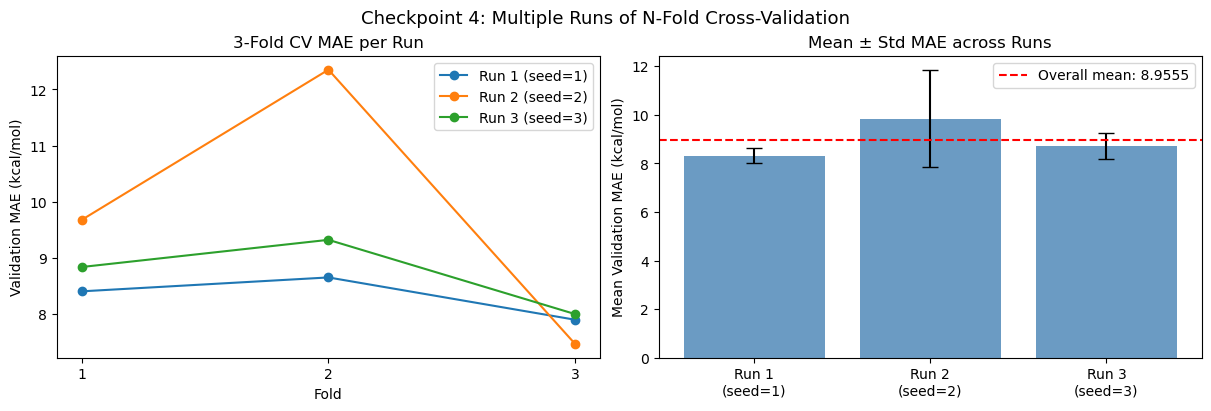

In [7]:

import random
from sklearn.model_selection import KFold

# ── Reproducibility helper ───────────────────────────────────────────────────
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ── Load dataset WITHOUT shuffle so indices are stable across folds ──────────
def load_ani_dataset_cv(dspath):
    """Same pipeline as checkpoint 3 but no .shuffle() call."""
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order  = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    # NOTE: no .shuffle() — fold indices must be stable
    return dataset


# Convert torchani dataset 
def dataset_to_list(dataset, batch_size=512):
    """
    Iterates through the torchani dataset and collects every sample into a
    plain Python list of dicts with keys: 'species', 'coordinates', 'energies'.
    All tensors are kept on CPU to save GPU memory during data preparation.
    """
    records = []
    loader  = dataset.collate(batch_size).cache()
    for batch in loader:
        species = batch['species'].cpu()      # (B, max_atoms)
        coords  = batch['coordinates'].cpu()  # (B, max_atoms, 3)
        energies = batch['energies'].cpu()    # (B,)
        for i in range(energies.shape[0]):
            records.append({
                'species':     species[i],
                'coordinates': coords[i],
                'energies':    energies[i],
            })
    return records


# Collate a list of records into a batch dict on the target device
def collate_records(records):
    """
    Stacks a list of single-sample dicts into a batched dict,
    padding species / coordinates to the longest molecule in the batch.
    """
    max_atoms = max(r['species'].shape[0] for r in records)

    species_list = []
    coords_list  = []
    energy_list  = []

    for r in records:
        n = r['species'].shape[0]
        pad = max_atoms - n

        sp = r['species']
        co = r['coordinates']

        if pad > 0:
            # torchani uses -1 as the padding species index
            sp = torch.cat([sp, torch.full((pad,), -1, dtype=sp.dtype)])
            co = torch.cat([co, torch.zeros(pad, 3, dtype=co.dtype)])

        species_list.append(sp)
        coords_list.append(co)
        energy_list.append(r['energies'])

    return {
        'species':     torch.stack(species_list),
        'coordinates': torch.stack(coords_list),
        'energies':    torch.stack(energy_list),
    }


# Lightweight DataLoader for plain-list folds
class ListDataLoader:
    """
    Wraps a list of single-sample dicts so ANITrainer can iterate over it
    exactly like a torchani collated loader (.collate().cache() replacement).
    """
    def __init__(self, records, batch_size):
        self.records    = records
        self.batch_size = batch_size

    def __iter__(self):
        for start in range(0, len(self.records), self.batch_size):
            batch_records = self.records[start: start + self.batch_size]
            yield collate_records(batch_records)


# Patched trainer methods that accept either torchani datasets OR list folds
# Rather than modifying ANITrainer (to keep ckpt 3 untouched), we subclass it.
class ANITrainerCV(ANITrainer):
    """
    Extends ANITrainer so that train() and evaluate() accept EITHER a torchani
    dataset object (checkpoint 3 behaviour) OR a plain list of sample dicts
    (checkpoint 4 KFold behaviour).
    """

    def _make_loader(self, data):
        """Returns an iterable of batched dicts regardless of data type."""
        if isinstance(data, list):
            return ListDataLoader(data, self.batch_size)
        # torchani dataset — original behaviour
        return data.collate(self.batch_size).cache()

    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()

        print("Initialize training data...")
        train_data_loader = self._make_loader(train_data)

        loss_func        = nn.MSELoss()
        train_loss_list  = []
        val_loss_list    = []
        lowest_val_loss  = np.inf
        weights          = None

        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            n_total          = 0.0

            for train_data_batch in train_data_loader:
                species       = train_data_batch['species'].to(device)
                coords        = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()

                _, pred_energies = self.model((species, coords))

                batch_loss = loss_func(true_energies, pred_energies)
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()

                batch_importance  = true_energies.shape[0]
                train_epoch_loss += batch_loss.item() * batch_importance
                n_total          += batch_importance

            train_epoch_loss /= max(n_total, 1)

            _, val_mae = self.evaluate(val_data, draw_plot=False, return_mae=True)

            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_mae)

            if early_stop and val_mae < lowest_val_loss:
                lowest_val_loss = val_mae
                weights = {k: v.clone() for k, v in self.model.state_dict().items()}

        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            ax.plot(range(len(train_loss_list)), train_loss_list, label='Train')
            ax.plot(range(len(val_loss_list)),   val_loss_list,   label='Validation MAE (kcal/mol)')
            ax.legend()
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
            plt.show()

        if early_stop and weights is not None:
            self.model.load_state_dict(weights)

        return train_loss_list, val_loss_list

    def evaluate(self, data, draw_plot=False, return_mae=False):
        self.model.eval()

        data_loader = self._make_loader(data)
        loss_func   = nn.MSELoss()
        total_loss  = 0.0

        true_energies_all = []
        pred_energies_all = []

        with torch.no_grad():
            for batch_data in data_loader:
                species       = batch_data['species'].to(device)
                coords        = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()

                _, pred_energies = self.model((species, coords))

                batch_loss        = loss_func(true_energies, pred_energies)
                batch_importance  = true_energies.shape[0]
                total_loss       += batch_loss.item() * batch_importance

                true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())

        true_energies_all = np.concatenate(true_energies_all)
        pred_energies_all = np.concatenate(pred_energies_all)

        hartree2kcalmol = 627.5094738898777
        mae = np.mean(np.abs(true_energies_all - pred_energies_all)) * hartree2kcalmol

        if draw_plot:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all,
                       label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()
            plt.show()

        if return_mae:
            return total_loss, mae
        return total_loss


# N-Fold Cross-Validation (single seed)

def run_kfold_cv(all_records, n_splits=3, seed=42,
                 hidden_layers=[128], dropout=0.1,
                 lr=1e-4, epochs=10, l2=1e-5, batch_size=256):
    """
    Runs N-fold cross-validation on a pre-materialised list of sample dicts.
    """
    set_seed(seed)
    kf        = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_maes = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(all_records), start=1):
        print(f"\n  Fold {fold}/{n_splits}  "
              f"(train={len(train_idx)}, val={len(val_idx)})")

        train_fold = [all_records[i] for i in train_idx]
        val_fold   = [all_records[i] for i in val_idx]

        model   = build_model(aev_computer, aev_dim, hidden_layers, dropout)
        trainer = ANITrainerCV(model,
                               batch_size=batch_size,
                               learning_rate=lr,
                               epoch=epochs,
                               l2=l2)

        trainer.train(train_fold, val_fold, early_stop=True, draw_curve=False)

        _, val_mae = trainer.evaluate(val_fold, return_mae=True)
        print(f"  Fold {fold} Val MAE: {val_mae:.4f} kcal/mol")
        fold_maes.append(val_mae)

    mean_mae = np.mean(fold_maes)
    std_mae  = np.std(fold_maes)

    print("\n  Cross-validation results:")
    print("  Fold MAEs:", [round(x, 4) for x in fold_maes])
    print(f"  Mean MAE : {mean_mae:.4f} kcal/mol")
    print(f"  Std  MAE : {std_mae:.4f} kcal/mol")

    return fold_maes, mean_mae, std_mae


# Prepare data once (materialise to list — done outside the loop for efficiency)
# =============================================================================

print("Loading dataset for cross-validation (no shuffle)...")
cv_dataset   = load_ani_dataset_cv(
    "/global/scratch/users/mahikabansal/c142_project/ani_gdb_s01_to_s04.h5"
)

print("Materialising dataset to list (this may take a minute)...")
all_records  = dataset_to_list(cv_dataset, batch_size=512)
print(f"Total samples: {len(all_records)}")

# Multiple Runs of N-Fold Cross-Validation
# Best hyperparameters from Checkpoint 3: hidden=[128], lr=1e-4,
#   dropout=0.1, l2=1e-5, epochs=10

seeds         = [1, 2, 3]
n_splits      = 3
all_run_means = []
all_run_stds  = []
all_run_folds = []

for run_num, seed in enumerate(seeds, start=1):
    print(f"\n{'='*55}")
    print(f"  RUN {run_num}/{len(seeds)}  (seed={seed})")
    print(f"{'='*55}")

    fold_maes, mean_mae, std_mae = run_kfold_cv(
        all_records,
        n_splits      = n_splits,
        seed          = seed,
        hidden_layers = [128],
        dropout       = 0.1,
        lr            = 1e-4,
        epochs        = 10,
        l2            = 1e-5,
        batch_size    = 256,
    )

    all_run_means.append(mean_mae)
    all_run_stds.append(std_mae)
    all_run_folds.append(fold_maes)


# Summary Table

print("\n" + "="*55)
print("MULTIPLE-RUN CROSS-VALIDATION SUMMARY")
print("="*55)

summary_rows = []
for run_num, (seed, folds, mean, std) in enumerate(
        zip(seeds, all_run_folds, all_run_means, all_run_stds), start=1):
    row = {'Run': run_num, 'Seed': seed}
    for f, mae in enumerate(folds, start=1):
        row[f'Fold {f} MAE'] = round(mae, 4)
    row['Mean MAE (kcal/mol)'] = round(mean, 4)
    row['Std MAE (kcal/mol)']  = round(std, 4)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

overall_mean = np.mean(all_run_means)
overall_std  = np.std(all_run_means)
print(f"\nOverall Mean MAE across all runs : {overall_mean:.4f} kcal/mol")
print(f"Overall Std  MAE across all runs : {overall_std:.4f} kcal/mol")


# Visualization

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Left: fold MAEs per run
ax = axes[0]
x  = np.arange(1, n_splits + 1)
for run_num, (folds, seed) in enumerate(zip(all_run_folds, seeds), start=1):
    ax.plot(x, folds, marker='o', label=f'Run {run_num} (seed={seed})')
ax.set_xlabel("Fold")
ax.set_ylabel("Validation MAE (kcal/mol)")
ax.set_title(f"{n_splits}-Fold CV MAE per Run")
ax.legend()
ax.set_xticks(x)

# Right: mean ± std per run
ax2 = axes[1]
run_labels = [f"Run {i+1}\n(seed={s})" for i, s in enumerate(seeds)]
ax2.bar(run_labels, all_run_means, yerr=all_run_stds,
        capsize=6, color='steelblue', alpha=0.8)
ax2.axhline(overall_mean, color='red', linestyle='--',
            label=f'Overall mean: {overall_mean:.4f}')
ax2.set_ylabel("Mean Validation MAE (kcal/mol)")
ax2.set_title("Mean ± Std MAE across Runs")
ax2.legend()

plt.suptitle("Checkpoint 4: Multiple Runs of N-Fold Cross-Validation", fontsize=13)
plt.show()